In [6]:
from glob import glob 

for g in glob('../../../../data/*.pdf'):
    print(g)

../../../../data\2040_seoul_plan.pdf
../../../../data\OneNYC_2050_Strategic_Plan.pdf
../../../../data\unsu.pdf


In [8]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

def read_pdf_and_split_text(pdf_path, chunk_size=1000, chunk_overlap=100):
    """
    주어진 PDF 파일을 읽고 텍스트를 분할합니다.
    매개변수:
        pdf_path (str): PDF 파일의 경로.
        chunk_size (int, 선택적): 각 텍스트 청크의 크기. 기본값은 1000입니다.
        chunk_overlap (int, 선택적): 청크 간의 중첩 크기. 기본값은 100입니다.
    반환값:
        list: 분할된 텍스트 청크의 리스트.
    """
    print(f"PDF: {pdf_path} -----------------------------")

    pdf_loader = PyPDFLoader(pdf_path)
    data_from_pdf = pdf_loader.load()

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunk_overlap
    )

    splits = text_splitter.split_documents(data_from_pdf)
    
    print(f"Number of splits: {len(splits)}\n")
    return splits


In [10]:
from langchain_chroma import Chroma
import os

##### Vectorstore 설정 #####

from langchain_huggingface import HuggingFaceEmbeddings

# 한국어 및 다국어 성능이 뛰어난 오픈소스 모델 사용
embedding = HuggingFaceEmbeddings(
    model_name="jhgan/ko-sroberta-multitask"
)

persist_directory='../../../../chroma_store'

if os.path.exists(persist_directory):
    print("Loading existing Chroma store")
    vectorstore = Chroma(
        persist_directory=persist_directory, 
        embedding_function=embedding
    )
else:
    print("Creating new Chroma store")
    
    vectorstore = None
    for g in glob('../../../../data/*.pdf'):
        chunks = read_pdf_and_split_text(g)
        # 100개씩 나눠서 저장
        for i in range(0, len(chunks), 100):
            if vectorstore is None:
                vectorstore = Chroma.from_documents(
                    documents=chunks[i:i+100],
                    embedding=embedding,
                    persist_directory=persist_directory
                )
            else:
                vectorstore.add_documents(
                    documents=chunks[i:i+100]
                )


Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 7453.78it/s]


Creating new Chroma store
PDF: ../../../../data\2040_seoul_plan.pdf -----------------------------
Number of splits: 308

PDF: ../../../../data\OneNYC_2050_Strategic_Plan.pdf -----------------------------
Number of splits: 1023

PDF: ../../../../data\unsu.pdf -----------------------------
Number of splits: 18



In [11]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

chunks = retriever.invoke("서울 온실가스 저감 계획")

for chunk in chunks:
    print(chunk.metadata)
    print(chunk.page_content)


{'total_pages': 205, 'page_label': '188', 'producer': 'Hancom PDF 1.3.0.542', 'page': 187, 'author': 'SI', 'pdfversion': '1.4', 'source': '../../../../data\\2040_seoul_plan.pdf', 'moddate': '2024-12-12T18:16:11+09:00', 'creator': 'Hwp 2020 11.0.0.5178', 'creationdate': '2024-12-12T18:16:11+09:00'}
180제6장 계획의 실현
부문지표명지표의 통계명내용 및 산정식출처목표치 및 관리방향
기후·환경
탄소중립온실가스 배출량건물·수송·폐기물 처리 등에 따른 서울의 온실가스 배출량서울시 내부자료(기후환경정책과)2005년 대비 70% 감축대기질개선초미세먼지 농도*서울시 대기 중 2.5㎛보다 작은 초미세먼지의 농도서울특별시 대기환경정보10㎍/㎥(2040)신재생에너지신재생에너지 보급률*서울시 총 에너지보급량 중 신·재생에너지 보급 비율한국에너지공단21%(2030)탄소배출감축건물 에너지 효율화 사업 수에너지다소비건물, 공공건물, 상업건물, 주택 등에 대한 건물에너지효율화 사업 개소수(누적) 서울시 내부자료(친환경건물과)100만 호(2026)자원순환인구당 생활폐기물 발생량(매립률)서울시민 1인당 하루 평균 생활폐기물 배출량(서울 하루 평균 생활폐기물 배출량/인구 수)과 생활폐기물 중 매립되는 비율 서울통계0.86㎏/인/일(2027)물순환물재이용량*빗물, 중수도시설, 하수처리수로 대체하여 이용한 물의 양서울시 내부자료(수변감성도시과)증가녹지환경만족녹지환경만족도시민이 현재 거주하는 지역의 녹지환경(공원, 숲 등)에 대하여 만족하는 정도서울서베이증가공원확충1인당 공원면적*공원 면적(도시자연공원구역+도시계획시설 공원+국립공원)/인구수서울시 공원통계증가수변공간활성화한강공원 이용객수산책, 낚시, 자전거, 인라인, 운동·수상시설, 수영장, 행사 등을 위하여 한강공

In [12]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="gemma4:e2b", base_url="http://127.0.0.1:11434") 
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 만나서 반갑습니다 😊', additional_kwargs={}, response_metadata={'model': 'gemma4:e2b', 'created_at': '2026-08-22T08:31:05.7225355Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6278515500, 'load_duration': 6106380300, 'prompt_eval_count': 18, 'prompt_eval_duration': 91516000, 'eval_count': 7, 'eval_duration': 76152000, 'logprobs': None, 'model_name': 'gemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--01a02898-376c-73c0-bb47-f7cd4d213764-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 7, 'total_tokens': 25})

In [13]:
# Router 설정
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal # 문자열 리터럴 타입을 지원하는 typing 모듈의 클래스
from pydantic import BaseModel, Field

# Data model
class RouteQuery(BaseModel):
    """사용자 쿼리를 가장 관련성이 높은 데이터 소스로 라우팅합니다."""
    
    datasource: Literal["vectorstore", "casual_talk"] = Field(
        ...,
        description="""
        사용자 질문에 따라 casual_talk 또는 vectorstore로 라우팅합니다.
        - casual_talk: 일상 대화를 위한 데이터 소스. 사용자가 일상적인 질문을 할 때 사용합니다.
        - vectorstore: 사용자 질문에 답하기 위해 RAG로 vectorstore 검색이 필요한 경우 사용합니다.
        """,
    )

In [14]:
# 특정 모델을 structured output (구조화된 출력)과 함께 사용하기 위해 설정
structured_llm_router = model.with_structured_output(RouteQuery)

router_system = """
당신은 사용자의 질문을 vectorstore 또는 casual_talk으로 라우팅하는 전문가입니다.
- vectorstore에는 서울, 뉴욕의 발전계획과 관련된 문서가 포함되어 있습니다. 이 주제에 대한 질문에는 vectorstore를 사용하십시오.
- 사용자의 질문이 일상 대화에 관련된 경우 casual_talk을 사용하십시오.
"""

# 시스템 메시지와 사용자의 질문을 포함하는 프롬프트 템플릿 생성
route_prompt = ChatPromptTemplate.from_messages([
    ("system", router_system),
    ("human", "{question}"),
])

# 라우터 프롬프트와 구조화된 출력 모델을 결합한 객체
question_router = route_prompt | structured_llm_router


In [15]:
print(
    question_router.invoke({
        "question": "서울 온실가스 저감 계획은 무엇인가요?"
    })
)

print(question_router.invoke({"question": "잘 지냈어?"}))

datasource='vectorstore'
datasource='casual_talk'


In [16]:
from langchain_core.prompts import PromptTemplate

class GradeDocuments(BaseModel):
    """검색된 문서가 질문과 관련성 있는지 yes 또는 no로 평가합니다."""

    binary_score: Literal["yes", "no"] = Field(
        description="문서가 질문과 관련이 있는지 여부를 'yes' 또는 'no'로 평가합니다."
    )

structured_llm_grader = model.with_structured_output(GradeDocuments)

In [17]:
grader_prompt = PromptTemplate.from_template("""
당신은 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 평가자입니다. \n 
문서에 사용자 질문과 관련된 키워드 또는 의미가 포함되어 있으면, 해당 문서를 관련성이 있다고 평가하십시오. \n
엄격한 테스트가 필요하지 않습니다. 목표는 잘못된 검색 결과를 걸러내는 것입니다. \n
문서가 질문과 관련이 있는지 여부를 나타내기 위해 'yes' 또는 'no'로 이진 점수를 부여하십시오.
                                             
Retrieved document: \n {document} \n\n 
User question: {question}
""")

retrieval_grader = grader_prompt | structured_llm_grader
question = "서울시 자율주행 관련 계획"
documents = retriever.invoke(question)

for doc in documents:
    print(doc)


page_content='5-1 미래교통수단과 융합을 위한 선제적 교통환경 구축5-1-1 신 교통수단·기술발전 등 미래 환경 변화에 대비한 인프라 구축·정비ŸUAM·전기차·자율주행차 등 미래교통수단의 상용화에 대비하여 첨단 기반시설과 빅데이터 플랫폼 등을 확충한다.-자율주행차의 시범 운영지역의 확대, 지역 거점별 특성에 맞는 다양한 서비스 구현, 서울 전역을 연결하는 자율주행 버스노선 설계 등-도로정밀지도, 교통데이터 등을 갖춘 스마트 도로 인프라 구축을 단계적·지속적으로 확대-미래 변화에 따라 도시계획시설의 기준, 건축법, 주차장법 등 제도적 개선방안 마련Ÿ항공 모빌리티의 친화성이 높은 지역을 중심으로 관련 인프라와 안전한 운영체계 구축 및 기존 교통체계와 연결을 도모하고 개발사업 추진 시에도 이에 대한 연계를 고려한다.5-1-2 통합 모빌리티 플랫폼 개발 지속 추진Ÿ도시공간의 위계에 따라 유형별 모빌리티 허브를 조성하여, 교통수단 간 편리한 환승을 지원하고 교통 외 다양한 도시기능을 통합적으로 제공할 수 있는 모빌리티 플랫폼 공간을 조성한다.-광역형: 서울 및 수도권의 주요 거점과 GTX, UAM 등 광역교통망을 연계하는 복합환승센터를 구축하고, 공공·상업시설 등 도시서비스를 제공하는 스마트 물류 플랫폼 구축-지역형: 4개 권역을 중심으로 하는 간선 통행거점 및 물류거점을 조성하고 공영주차장, 차고지 등 기존교통시설 입체화 추진 -근린형: 개인형 이동장치(PM: Personal Mobility), 공유형 이동 수단 등에 대한 공유시설, 소규모 주차장, 정류소 등 기존 교통시설과 접목Ÿ기존의 교통수단과 자율주행자동차, UAM, 마이크로모빌리티 등 새롭게 등장하는 다양한 교통수단을 통합하여 관제하고 운영·관리할 수 있는 기반을 조성한다.Ÿ대중교통 중심의 통합 모빌리티 플랫폼을 구축하여 다양한 이동 수단에 대한 정보를 통합하고 최적의 통합교통 서비스(MaaS: Mobility as a Service)를 제공하여, 교통의 효율성을 제고한다.Ÿ각종 교통 규제를 완화

In [18]:
filtered_docs = []

for i, doc in enumerate(documents):
    print(f"Document {i + 1}:")
    is_relevant = retrieval_grader.invoke({"question": question, "document": doc.page_content})
    print(is_relevant)
    print(doc.page_content[:200])
    print("=================================\n\n")

    if is_relevant.binary_score == "yes":
        filtered_docs.append(doc)

print(f"Filtered documents: {len(filtered_docs)}")


Document 1:
binary_score='yes'
5-1 미래교통수단과 융합을 위한 선제적 교통환경 구축5-1-1 신 교통수단·기술발전 등 미래 환경 변화에 대비한 인프라 구축·정비ŸUAM·전기차·자율주행차 등 미래교통수단의 상용화에 대비하여 첨단 기반시설과 빅데이터 플랫폼 등을 확충한다.-자율주행차의 시범 운영지역의 확대, 지역 거점별 특성에 맞는 다양한 서비스 구현, 서울 전역을 연결하는 자율주행 버스


Document 2:
binary_score='no'
4제1장 개요
2. 계획의 범위시간적 범위: 기준연도 2019년, 목표연도 2040년Ÿ2040 서울도시기본계획에서는 계획의 기준연도를 2019년으로 하여 서울의 인구·산업·경제·환경·교통·주택 등 부문별 현황을 파악하고, 대내외적인 여건 변화 분석과 시민·전문가·행정 등 다양한 주체의 의견을 수렴하여 미래상과 부문별 전략계획, 공간계획 등 도시 전반에 대한


Document 3:
binary_score='no'
제2절 상시 모니터링체계 운영177
제2절 상시 모니터링체계 운영1. 계획 모니터링의 개요모니터링의 필요성 및 추진 현황Ÿ2040 서울도시기본계획은 주택, 정비, 교통, 환경, 안전, 산업, 사회, 문화 등 다양한 부문을 다루면서 장기적 목표를 제시하는 계획이다. 이러한 특성에 따라 계획의 실효성을 높이고 정책을 일관적으로 추진하기 위해서는 도시의 여건 변


Document 4:
binary_score='yes'
제3절 2040 서울도시기본계획 7대 목표45
제3절2040 서울도시기본계획 7대 목표
Ÿ2040 서울도시기본계획에서는 미래상인 ‘살기 좋은 나의 서울, 세계 속에 모두의 서울’을 도시공간에 구체화하기 위해서 아래 7개의 목표를 설정하였다.구 분 7대 목표 주요 내용어디서나누릴 수 있는 “삶의 질”1걸어서 누리는 다양한 일상, ‘보행일상권 조성’ 주거·일자


Document 5:
binary_score='yes'
36제2장 미래상과 목표
6) 미래교통수단의 등장과 첨단 인프라

In [19]:
### Generate
# PromptTemplate을 사용하여 RAG를 위한 프롬프트를 생성합니다.

rag_generate_system = """
너는 사용자의 질문에 대해 주어진 context에 기반하여 답변하는 도시 계획 전문가이다. 
주어진 context는 vectorstore에서 검색된 결과이다. 
주어진 context를 기반으로 사용자의 question에 대해 답변하라.

=================================
question: {question}
context: {context}
"""

# PromptTemplate을 생성하여 question과 context를 포맷팅
rag_prompt = PromptTemplate(
    input_variables=["question", "context"],
    template=rag_generate_system
)

# rag chain
rag_chain = rag_prompt | model 

# 사용자 질문과 검색된 문서를 입력으로 사용하여 RAG를 실행
question = "서울시 자율주행 관련 계획"

rag_chain.invoke({"question": question, "context": filtered_docs})


AIMessage(content='도시 계획 전문가로서 주어진 문서를 바탕으로 서울시의 자율주행 관련 계획을 다음과 같이 요약하여 답변드립니다.\n\n서울시는 자율주행차 및 미래 교통 수단의 상용화에 대비하여 첨단 기반시설과 통합 모빌리티 플랫폼 구축을 목표로 교통 환경 전반의 혁신을 추진하고 있습니다.\n\n**1. 스마트 도로 인프라 구축 및 데이터 기반 마련**\n*   **스마트 도로 인프라 확대:** 도로 정밀 지도와 교통 데이터를 갖춘 스마트 도로 인프라를 단계적이고 지속적으로 확대하여 자율주행 환경을 조성합니다.\n*   **데이터 활용:** 교통 데이터 등을 기반으로 효율적인 교통 관제 및 운영 시스템을 구축합니다.\n\n**2. 통합 모빌리티 플랫폼 개발**\n*   **통합 플랫폼 구축:** 교통 수단 간의 편리한 환승을 지원하고 다양한 도시 기능을 통합적으로 제공하기 위해 통합 모빌리티 플랫폼을 개발합니다.\n*   **MaaS 제공:** 대중교통 중심의 통합 모빌리티 플랫폼을 구축하여 다양한 이동 수단에 대한 정보를 통합하고 최적의 통합교통 서비스(MaaS: Mobility as a Service)를 제공함으로써 교통의 효율성을 제고합니다.\n\n**3. 미래 교통 수단과의 융합 및 운영 체계 구축**\n*   **다양한 교통수단 통합 관리:** 기존 교통수단과 자율주행자동차, UAM(도심항공모빌리티), 마이크로모빌리티 등 새롭게 등장하는 다양한 교통수단을 통합하여 관제하고 운영·관리할 수 있는 기반을 조성합니다.\n*   **자율주행 서비스 구현:** 자율주행차의 시범 운영 지역을 확대하고, 지역 거점별 특성에 맞는 서비스를 구현하며, 서울 전역을 연결하는 자율주행 버스 노선 설계 등을 추진합니다.\n*   **항공 모빌리티 연계:** 항공 모빌리티의 친화성이 높은 지역을 중심으로 관련 인프라와 안전한 운영체계를 구축하고 기존 교통체계와의 연계를 도모합니다.\n\n결론적으로, 서울시는 자율주행 및 미래 교통 변화에 선제적으로 대응하기 위

In [20]:
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    question: str   # 사용자 질문
    generation: str # LLM 생성 결과
    documents: List[str] # 검색된 문서


In [21]:
def route_question(state): 
    """
    사용자 질문을 vectorstore 또는 casual_talk로 라우팅합니다.
    
    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 라우팅된 데이터 소스와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------ROUTE------')
    question = state['question']
    route = question_router.invoke({"question": question})

    
    print(f"---Routing to {route.datasource}---")
    return route.datasource   

In [22]:
def retrieve(state): 
    """
    vectorstore에서 질문에 대한 문서를 검색합니다.
    
    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 검색된 문서와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------RETRIEVE------')
    question = state['question']

    # Retrieve documents
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

In [23]:
def grade_documents(state):
    """
    검색된 문서를 평가하여 질문과 관련성이 있는지 확인합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 관련성이 있는 문서와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------GRADE------')
    question = state['question']
    documents = state['documents']
    filtered_docs = []

    for i, doc in enumerate(documents):
        is_relevant = retrieval_grader.invoke({"question": question, "document": doc.page_content})
        if is_relevant.binary_score == "yes":
            filtered_docs.append(doc)
    return {"documents": filtered_docs, "question": question}  

In [24]:
def generate(state):
    """
    LLM을 사용하여 문서와 사용자 질문에 대한 답변을 생성합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): LLM 생성 결과와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------GENERATE------')
    question = state['question']
    documents = state['documents']
    generation = rag_chain.invoke({"question": question, "context": documents})
    return {
        "documents": documents,
        "question": question,
        "generation": generation
    }

In [25]:
def casual_talk(state):
    """
    일상 대화를 위한 답변을 생성합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 일상 대화 결과와 사용자 질문을 포함하는 새로운 graph state
    """
    print('------CASUAL TALK------')
    question = state['question']
    generation = model.invoke(question)
    return {
        "question": question,
        "generation": generation
    }

In [26]:
from langgraph.graph import START, StateGraph, END

workflow = StateGraph(GraphState)

In [27]:
# 노드를 정의 
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("casual_talk", casual_talk)

In [28]:
# graph를 정의
workflow.add_conditional_edges(
    START, 
    route_question,
    {
        "vectorstore": "retrieve",
        "casual_talk": "casual_talk"
    }
)
workflow.add_edge("casual_talk", END)
workflow.add_edge("retrieve", "grade_documents")
workflow.add_edge("grade_documents", "generate")
workflow.add_edge("generate", END)

app = workflow.compile() # workflow를 컴파일

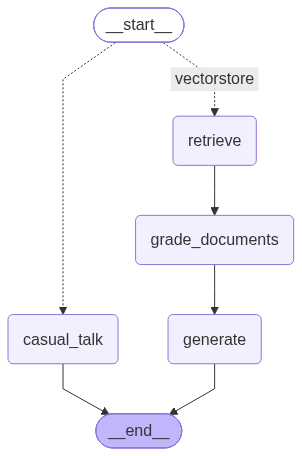

In [29]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    #  실패 시 통과
    pass


In [30]:
inputs = {
    "question": "서울시 자율주행 계획"
}

app.invoke(inputs) # workflow를 실행합니다.

------ROUTE------
---Routing to vectorstore---
------RETRIEVE------
------GRADE------
------GENERATE------


{'question': '서울시 자율주행 계획',
 'generation': AIMessage(content='저는 도시 계획 전문가로서 주어진 Context를 기반으로 서울시의 자율주행 계획에 대해 답변드리겠습니다.\n\n제공된 문헌에 따르면, 서울시는 자율주행차 및 미래 교통수단의 상용화에 대비하여 첨단 기반시설과 빅데이터 플랫폼을 확충하는 것을 목표로 하고 있으며, 이를 위해 다음과 같은 방향으로 계획을 추진하고 있습니다.\n\n### 1. 첨단 기반시설 및 인프라 구축\n*   **스마트 도로 인프라 구축:** 도로 정밀지도 및 교통 데이터를 확보하여 스마트 도로 인프라를 단계적이고 지속적으로 확대할 계획입니다.\n*   **첨단 기반시설 확충:** 자율주행차, UAM(도심항공모빌리티) 등 미래 교통수단의 상용화에 대비하기 위해 첨단 기반시설을 확충합니다.\n\n### 2. 자율주행 서비스 운영 및 시스템 구축\n*   **시범 운영 확대:** 자율주행차의 시범 운영 지역을 확대하고, 지역 거점별 특성에 맞는 다양한 서비스를 구현합니다.\n*   **노선 설계:** 서울 전역을 연결하는 자율주행 버스 노선 설계를 추진합니다.\n*   **안전 및 제도 개선:** 자율주행차와 기존 교통수단의 안전하고 효율적인 조화를 도모하고, 새로운 교통수단 정착을 위한 통합적인 교통수단 정착 가이드라인 마련 및 관련 제도의 개선을 추진합니다.\n\n### 3. 통합 모빌리티 플랫폼 구축\n*   **통합 플랫폼 개발:** 기존 교통수단과 자율주행자동차, UAM, 마이크로모빌리티 등 새롭게 등장하는 다양한 교통수단을 통합하여 관제하고 운영·관리할 수 있는 기반을 조성합니다.\n*   **MaaS 제공:** 대중교통 중심의 통합 모빌리티 플랫폼을 구축하여 다양한 이동 수단에 대한 정보를 통합하고 최적의 통합교통 서비스(MaaS: Mobility as a Service)를 제공함으로써 교통의 효율성을 제고합니다.\n\n요약하자면, 서울시의 자율주행 계획은 첨단 인프라를 기반

In [31]:
inputs = {
    "question": "잘 지내고 있어?"
}

app.invoke(inputs) # workflow를 실행합니다.

------ROUTE------
---Routing to casual_talk---
------CASUAL TALK------


{'question': '잘 지내고 있어?',
 'generation': AIMessage(content='네, 잘 지내고 있어요! 😊\n\n**당신은요?** (How about you?)', additional_kwargs={}, response_metadata={'model': 'gemma4:e2b', 'created_at': '2026-08-22T08:42:07.0633156Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2694516000, 'load_duration': 4712700, 'prompt_eval_count': 22, 'prompt_eval_duration': 27686000, 'eval_count': 314, 'eval_duration': 2651894000, 'logprobs': None, 'model_name': 'gemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--01a028a2-5cd0-7511-8aca-c4a78a31c5ce-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 22, 'output_tokens': 314, 'total_tokens': 336})}

In [32]:
inputs = {
    "question": "서울시의 자율주행 차량 관련 계획은 무엇이 있나요?"
}

for msg, meta in app.stream(inputs, stream_mode='messages'):
    print(msg.content, end='')


------ROUTE------
{
"datasource": "vectorstore"
}---Routing to vectorstore---
------RETRIEVE------
------GRADE------
{
  "binary_score": "yes"
}{
"binary_score": "yes"
}{
"binary_score": "no"
}{
  "binary_score": "yes"
}{
"binary_score": "no"
}------GENERATE------
제공된 컨텍스트를 기반으로 서울시의 자율주행 차량 관련 계획은 다음과 같이 요약할 수 있습니다.

서울시는 미래 교통수단과 자율주행차의 상용화에 대비하여 첨단 기반시설 및 플랫폼 구축을 목표로 다양한 계획을 추진하고 있습니다.

**1. 첨단 기반시설 및 데이터 플랫폼 확충:**
*   **인프라 확충:** 자율주행차, UAM(도심항공교통), 전기차 등 미래 교통수단의 상용화에 대비하기 위해 첨단 기반시설을 확충합니다.
*   **스마트 도로 인프라 구축:** 도로 정밀지도 및 교통데이터를 갖춘 스마트 도로 인프라를 단계적·지속적으로 확대하여 자율주행 환경을 조성합니다.
*   **빅데이터 플랫폼 활용:** 미래 교통수단 관련 빅데이터 플랫폼을 구축하여 교통 효율성을 제고하고 관리합니다.

**2. 자율주행 관련 서비스 및 노선 설계:**
*   **시범 운영 확대:** 자율주행차의 시범 운영 지역을 확대하고, 지역 거점별 특성에 맞는 다양한 서비스를 구현하는 것을 목표로 합니다.
*   **자율주행 버스노선 설계:** 서울 전역을 연결하는 자율주행 버스 노선 설계를 추진합니다.

**3. 통합 모빌리티 플랫폼 구축:**
*   **통합 관제 및 운영 기반 조성:** 기존 교통수단과 자율주행자동차, UAM, 마이크로모빌리티 등 다양한 교통수단을 통합하여 관제하고 운영·관리할 수 있는 기반을 조성합니다.
*   **통합 교통 서비스 제공:** 대중교통 중심의 통합 모빌리티 플랫폼을 구축하여 다양한